In [1]:
!pip install numpy matplotlib opencv-python plotly

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import plotly.graph_objects as go

In [3]:
def generate_sphere(n=12000):
    phi = np.random.uniform(0, np.pi, n)
    theta = np.random.uniform(0, 2*np.pi, n)

    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)

    return np.vstack((x,y,z)).T

points_3d = generate_sphere()
print("3D points:", points_3d.shape)

3D points: (12000, 3)


In [4]:
def look_at(cam_pos):
    forward = -cam_pos / np.linalg.norm(cam_pos)
    tmp = np.array([0,1,0])

    right = np.cross(tmp, forward)
    right /= np.linalg.norm(right)

    up = np.cross(forward, right)

    R = np.vstack([right, up, forward])
    T = cam_pos

    return R, T

In [5]:
def project(points, R, T, f=300, img_size=256):
    pts = (R @ (points - T).T).T

    valid = pts[:,2] > 0
    pts = pts[valid]

    x = f * pts[:,0] / pts[:,2] + img_size/2
    y = f * pts[:,1] / pts[:,2] + img_size/2

    return np.stack([x,y], axis=1)

In [6]:
num_views = 20
img_size = 256

silhouettes = []
R_all = []
T_all = []

for i in range(num_views):
    angle = 2*np.pi*i/num_views
    cam_pos = np.array([3*np.cos(angle), 0.5, 3*np.sin(angle)])

    R, T = look_at(cam_pos)
    proj = project(points_3d, R, T)

    img = np.zeros((img_size, img_size), dtype=np.uint8)

    for p in proj:
        x, y = int(p[0]), int(p[1])
        if 0 <= x < img_size and 0 <= y < img_size:
            img[y, x] = 255

    # 🔥 KEY FIX: make silhouette SOLID
    img = cv2.dilate(img, np.ones((7,7), np.uint8))
    img = cv2.GaussianBlur(img, (9,9), 0)
    img = (img > 20).astype(np.float32)

    silhouettes.append(img)
    R_all.append(R)
    T_all.append(T)

silhouettes = np.array(silhouettes)
R_all = np.array(R_all)
T_all = np.array(T_all)

print("Silhouettes:", silhouettes.shape)

Silhouettes: (20, 256, 256)


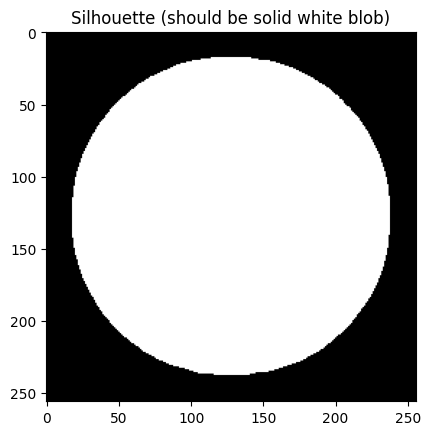

In [7]:
plt.imshow(silhouettes[0], cmap='gray')
plt.title("Silhouette (should be solid white blob)")
plt.show()

In [8]:
def create_voxels(res=60):
    x = np.linspace(-1.5, 1.5, res)
    grid = np.array(np.meshgrid(x,x,x))
    return grid.reshape(3,-1).T

voxels = create_voxels(60)
occupancy = np.ones(len(voxels), dtype=bool)

print("Total voxels:", len(voxels))

Total voxels: 216000


In [9]:
def project_voxel(v, R, T, f=300, img_size=256):
    X = R @ (v - T)

    if X[2] <= 0:
        return None

    x = f * X[0]/X[2] + img_size/2
    y = f * X[1]/X[2] + img_size/2

    return int(x), int(y)

In [10]:
for view_idx in range(num_views):
    R = R_all[view_idx]
    T = T_all[view_idx]
    sil = silhouettes[view_idx]

    for i, v in enumerate(voxels):
        if not occupancy[i]:
            continue

        proj = project_voxel(v, R, T)
        if proj is None:
            continue

        x, y = proj

        if 0 <= x < img_size and 0 <= y < img_size:
            if sil[y, x] < 0.1:
                occupancy[i] = False

In [11]:
remaining = np.sum(occupancy)
print("Remaining voxels:", remaining)

Remaining voxels: 42965


In [12]:
import plotly.io as pio
pio.renderers.default = 'browser'

In [13]:
hull = voxels[occupancy]

print("Rendering...")

#  Downsample for speed
max_pts = 8000
if len(hull) > max_pts:
    idx = np.random.choice(len(hull), max_pts, replace=False)
    hull = hull[idx]

x, y, z = hull[:,0], hull[:,1], hull[:,2]

fig = go.Figure(data=[go.Scatter3d(
    x=x,
    y=y,
    z=z,
    mode='markers',
    marker=dict(size=2)
)])

fig.update_layout(
    title="Final Visual Hull",
    scene=dict(
        xaxis=dict(range=[-1.5,1.5]),
        yaxis=dict(range=[-1.5,1.5]),
        zaxis=dict(range=[-1.5,1.5])
    )
)

fig.show()

Rendering...
